# Model Performance Comparison

This notebook aggregates, analyzes, and visualizes the comparative performance of five machine learning models—Random Forest, Artificial Neural Network (ANN), Long Short-Term Memory (LSTM), XGBoost, and LightGBM—on the task of predicting nucleotide changes across key Dengue virus (DENV) genome regions (Envelope E protein, 5′UTR, and 3′UTR) based solely on environmental variables (temperature and atmospheric CO₂).

### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from functools import reduce

### Load saved metrics

In [2]:
per_position_rf = pd.read_csv('../results/rf_per_position_accuracy.csv')
per_position_ann = pd.read_csv('../results/ann_per_position_accuracy.csv')
per_position_lstm = pd.read_csv('../results/lstm_per_position_accuracy.csv')
per_position_xgb = pd.read_csv('../results/xgb_per_position_accuracy.csv')
per_position_lgb = pd.read_csv('../results/lgb_per_position_accuracy.csv')

In [3]:
report_rf = pd.read_csv('../results/rf_per_position_classification_report.csv')
report_ann = pd.read_csv('../results/ann_per_position_classification_report.csv')
report_lstm = pd.read_csv('../results/lstm_per_position_classification_report.csv')
report_xgb = pd.read_csv('../results/xgb_per_position_classification_report.csv')
report_lgb = pd.read_csv('../results/lgb_per_position_classification_report.csv')

## Per-Position Accuracy

### Merge per-position accuracy of all models

In [4]:
# Rename 'accuracy' column
per_position_rf = per_position_rf.rename(columns={'accuracy': 'accuracy_rf'})
per_position_ann = per_position_ann.rename(columns={'accuracy': 'accuracy_ann'})
per_position_lstm = per_position_lstm.rename(columns={'accuracy': 'accuracy_lstm'})
per_position_xgb = per_position_xgb.rename(columns={'accuracy': 'accuracy_xgb'})
per_position_lgb = per_position_lgb.rename(columns={'accuracy': 'accuracy_lgb'})

# Merge all on 'position'
dfs = [per_position_rf, per_position_ann, per_position_lstm, per_position_xgb, per_position_lgb]
per_position_accuracy = reduce(lambda left, right: pd.merge(left, right, on='position'), dfs)

per_position_accuracy.head()

,position,accuracy_rf,accuracy_ann,accuracy_lstm,accuracy_xgb,accuracy_lgb
0,p_1,0.583333,0.009259,0.564815,0.574074,0.555556
1,p_2,0.462963,0.037037,0.351852,0.462963,0.462963
2,p_3,0.527778,0.037037,0.388889,0.537037,0.564815
3,p_4,0.601852,0.018519,0.564815,0.620370,0.629630
4,p_5,0.583333,0.037037,0.583333,0.611111,0.611111


### Boxplot of per-position accuracy for all models

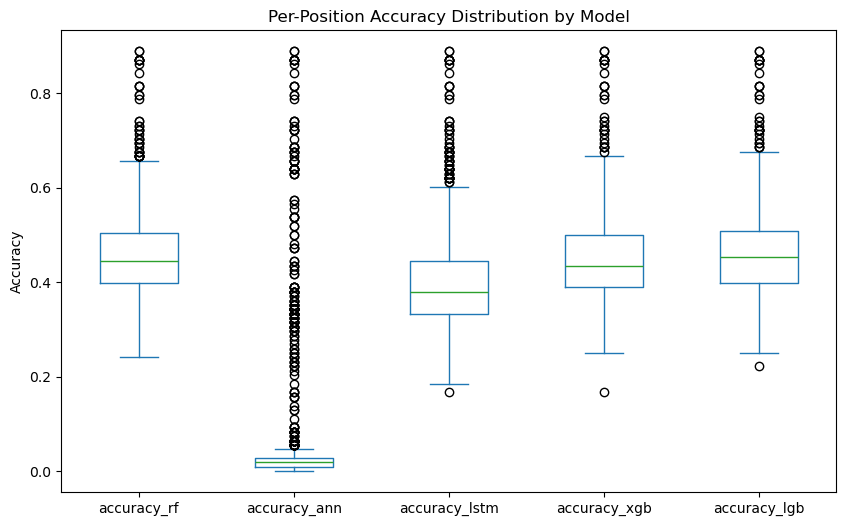

In [5]:
per_position_accuracy.set_index('position').plot(kind='box', figsize=(10,6))
plt.title('Per-Position Accuracy Distribution by Model')
plt.ylabel('Accuracy')
plt.show()

### Analysis of Per-Position Accuracy Distribution by Model

The above boxplot displays the distribution of per-position nucleotide prediction accuracy across the DENV genome for each evaluated model: Random Forest (RF), Artificial Neural Network (ANN), Long Short-Term Memory (LSTM), XGBoost, and LightGBM. Each box summarizes the spread of accuracy values at individual nucleotide positions on the test set.

#### **Key Observations:**

- **Overall Model Comparison:**  
  Tree-based models (RF, XGBoost, LightGBM) and LSTM show substantially higher and more consistent per-position accuracy compared to the ANN model. The median and interquartile range (IQR) for these models are tightly clustered around 0.4–0.5, while ANN’s distribution is highly compressed near zero.

- **Random Forest, XGBoost, and LightGBM:**  
  These models exhibit comparable performance, with median per-position accuracy just above 0.4 and a relatively compact IQR. Their accuracy distributions show a small spread, with few outliers reaching higher values. LightGBM’s box appears slightly higher.

- **LSTM:**  
  LSTM displays a lower median and wider spread than the tree-based models but still outperforms ANN by a significant margin. This suggests that even with only environmental predictors, sequence-aware architectures can partially capture predictive signal.

- **ANN:**  
  The ANN model’s box is compressed at the bottom of the plot, with a median and IQR near zero, indicating very poor per-position predictive ability on this task. This result suggests that basic feedforward neural networks struggle to model the complex dependencies between environmental features and nucleotide identity.

- **Outliers and Range:**  
  All models exhibit some high-value outliers (>0.7), which likely correspond to conserved or trivial-to-predict genomic positions, such as regions with padding or strong evolutionary constraint.

### Line plot of per-position accuracy for all models

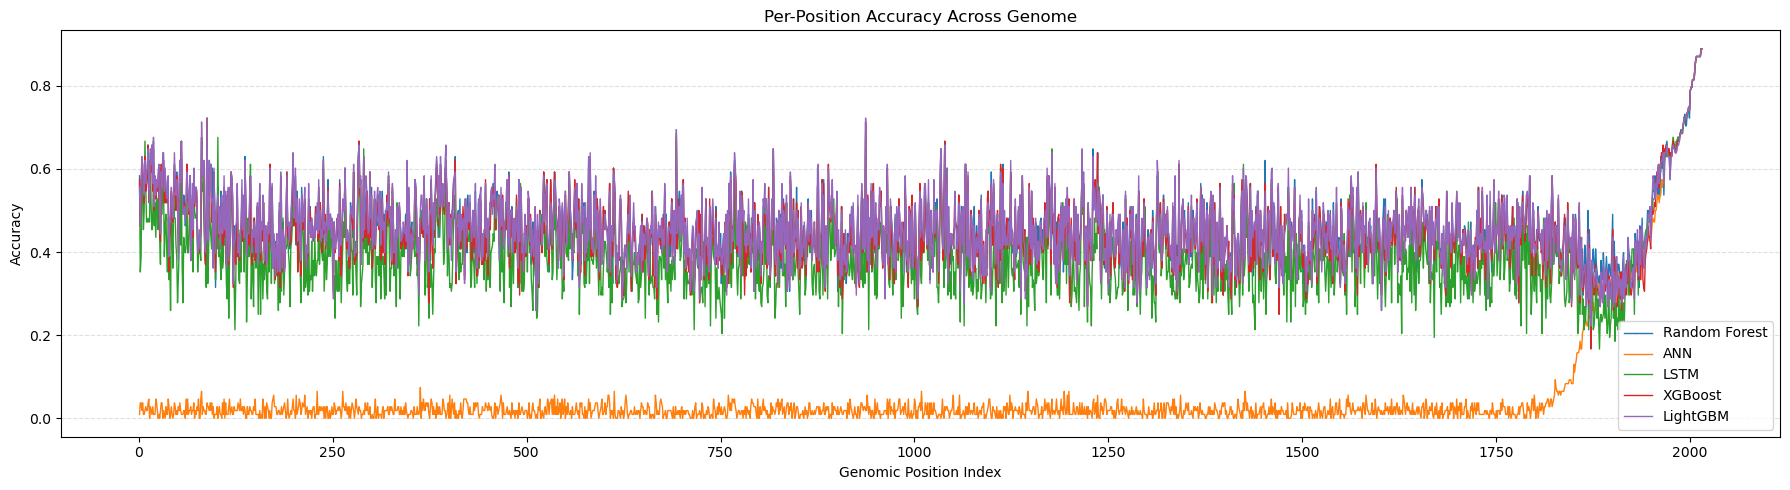

In [6]:
plt.figure(figsize=(18, 5))

per_position_accuracy['position_index'] = per_position_accuracy['position'].str.extract(r'(\d+)').astype(int)

plt.plot(per_position_accuracy['position_index'], per_position_accuracy['accuracy_rf'], label='Random Forest', linewidth=1)
plt.plot(per_position_accuracy['position_index'], per_position_accuracy['accuracy_ann'], label='ANN', linewidth=1)
plt.plot(per_position_accuracy['position_index'], per_position_accuracy['accuracy_lstm'], label='LSTM', linewidth=1)
plt.plot(per_position_accuracy['position_index'], per_position_accuracy['accuracy_xgb'], label='XGBoost', linewidth=1)
plt.plot(per_position_accuracy['position_index'], per_position_accuracy['accuracy_lgb'], label='LightGBM', linewidth=1)

plt.xlabel('Genomic Position Index')
plt.ylabel('Accuracy')
plt.title('Per-Position Accuracy Across Genome')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Accuracy Across Genome

The above line plot visualizes the per-position nucleotide prediction accuracy across the entire DENV genome for each model: Random Forest (RF), Artificial Neural Network (ANN), Long Short-Term Memory (LSTM), XGBoost, and LightGBM. Each line traces the accuracy at every genomic position, allowing direct comparison of model performance at high resolution.

#### **Key Observations:**

- **Tree-Based Models & LSTM Consistency:**  
  Random Forest, XGBoost, and LightGBM exhibit highly overlapping accuracy profiles across most positions, with LightGBM and XGBoost lines typically at the top. LSTM, while slightly below the tree-based models for much of the genome, shows reasonable consistency, especially in the E and 3′UTR regions.

- **ANN Underperformance:**  
  The ANN line is distinctly separated and clustered near the bottom (close to zero) across all positions, visually confirming its inability to learn the mapping from environmental variables to nucleotide identity. This poor performance persists throughout the entire genome.

- **Conserved or Trivial Positions:**  
  All models show a marked spike in accuracy at the extreme right of the plot (distal 3′UTR region), where accuracy approaches 0.9. This likely corresponds to regions with highly conserved nucleotides or padded sequence ends, where the prediction task becomes trivial.

- **Genomic Region Trends:**  
  Across the E protein and much of the 5′UTR, there is little fluctuation in the ranking of models; the three tree-based methods and LSTM remain above ANN, with moderate variation in accuracy at mutation-prone or diverse sites.

- **Fine-Scale Differences:**  
  While RF, XGBoost, and LightGBM are nearly indistinguishable visually for much of the genome, slight local differences may exist at specific nucleotide positions, reflecting nuanced differences in each algorithm’s handling of class imbalance or feature splits.

## Per-Position Macro F1

### Merge per-position macro f1 of all models

In [7]:
# Rename macro_f1 columns for each model
report_rf   = report_rf.rename(columns={'macro_f1': 'f1_rf'})
report_ann  = report_ann.rename(columns={'macro_f1': 'f1_ann'})
report_lstm = report_lstm.rename(columns={'macro_f1': 'f1_lstm'})
report_xgb  = report_xgb.rename(columns={'macro_f1': 'f1_xgb'})
report_lgb  = report_lgb.rename(columns={'macro_f1': 'f1_lgb'})

# Keep only the relevant columns
rf   = report_rf[['position', 'f1_rf']]
ann  = report_ann[['position', 'f1_ann']]
lstm = report_lstm[['position', 'f1_lstm']]
xgb  = report_xgb[['position', 'f1_xgb']]
lgb  = report_lgb[['position', 'f1_lgb']]

# Merge all on 'position'
dfs = [rf, ann, lstm, xgb, lgb]
per_position_macro_f1 = reduce(lambda left, right: pd.merge(left, right, on='position'), dfs)

per_position_macro_f1.head()

,position,f1_rf,f1_ann,f1_lstm,f1_xgb,f1_lgb
0,p_1,0.386225,0.012121,0.180473,0.366420,0.348638
1,p_2,0.361598,0.034043,0.130137,0.361790,0.359996
2,p_3,0.460420,0.032000,0.140000,0.465646,0.489319
3,p_4,0.391375,0.034783,0.180473,0.424410,0.396634
4,p_5,0.303182,0.022535,0.184211,0.367970,0.305526


### Boxplot of per-position macro f1 for all models

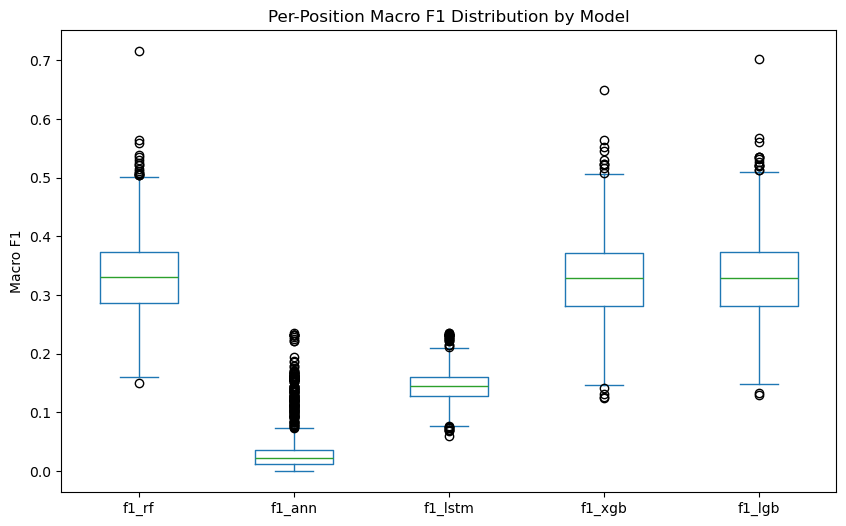

In [8]:
per_position_macro_f1.set_index('position').plot(kind='box', figsize=(10,6))
plt.title('Per-Position Macro F1 Distribution by Model')
plt.ylabel('Macro F1')
plt.show()

### Analysis of Per-Position Macro F1 Distribution by Model

The above boxplot compares the distribution of per-position macro F1-scores for each model (Random Forest, ANN, LSTM, XGBoost, LightGBM). The macro F1-score reflects the balance between precision and recall across all classes, making it a stringent metric for multi-class genomic prediction.

#### **Key Observations:**

- **Tree-Based Models Lead:**  
  Random Forest, XGBoost, and LightGBM demonstrate very similar distributions, with median macro F1-scores around 0.33 and upper quartiles above 0.4. This indicates strong, consistent classification performance across most positions for these models.

- **LSTM Intermediate:**  
  LSTM achieves a higher median macro F1-score than ANN, but remains well below the tree-based models. Its interquartile range suggests modest but stable predictive ability, showing it is more effective than a simple ANN for this task.

- **ANN Underperformance:**  
  The ANN model has an extremely low distribution of macro F1-scores, with the median near zero. This reflects its inability to provide meaningful multi-class predictions given the input features, further reinforcing its unsuitability for this problem.

- **Upper Bound & Outliers:**  
  All models share a similar maximum macro F1-score, corresponding to trivially predictable or conserved positions. However, the bulk of scores for the tree-based models are much higher than for ANN or LSTM.

### Line plot of per-position macro f1 for all models

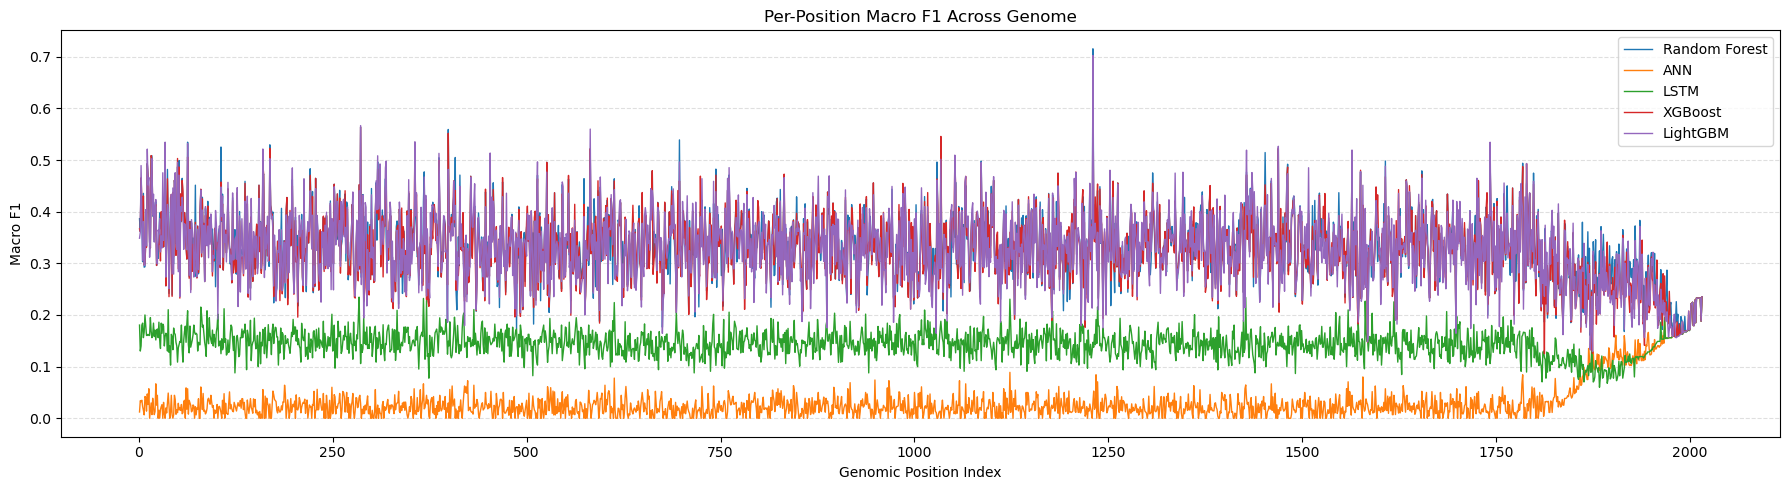

In [9]:
plt.figure(figsize=(18, 5))

per_position_macro_f1['position_index'] = per_position_macro_f1['position'].str.extract(r'(\d+)').astype(int)

plt.plot(per_position_macro_f1['position_index'], per_position_macro_f1['f1_rf'], label='Random Forest', linewidth=1)
plt.plot(per_position_macro_f1['position_index'], per_position_macro_f1['f1_ann'], label='ANN', linewidth=1)
plt.plot(per_position_macro_f1['position_index'], per_position_macro_f1['f1_lstm'], label='LSTM', linewidth=1)
plt.plot(per_position_macro_f1['position_index'], per_position_macro_f1['f1_xgb'], label='XGBoost', linewidth=1)
plt.plot(per_position_macro_f1['position_index'], per_position_macro_f1['f1_lgb'], label='LightGBM', linewidth=1)

plt.xlabel('Genomic Position Index')
plt.ylabel('Macro F1')
plt.title('Per-Position Macro F1 Across Genome')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Macro F1 Across Genome

The above line plot presents the per-position macro F1-score for each model (Random Forest, ANN, LSTM, XGBoost, LightGBM) across all genomic positions in the concatenated DENV genome (5′UTR, E protein, and 3′UTR regions). Macro F1 provides a holistic measure of multi-class performance at each nucleotide position, capturing both precision and recall across all classes.

#### **Key Observations:**

- **Consistent Tree-Based Performance:**  
  Random Forest, XGBoost, and LightGBM consistently exhibit the highest macro F1-scores across the genome, with highly overlapping lines and little performance drop even in variable regions. Their scores remain above 0.25–0.4 for the majority of positions, indicating robust, stable, and balanced classification power.

- **LSTM Outperforms ANN but Trails Tree Models:**  
  The LSTM model, while clearly outperforming the ANN, maintains a lower and flatter macro F1 curve (generally 0.13–0.18) across most positions. It demonstrates moderate capability but does not reach the predictive quality of the tree-based models.

- **ANN Shows Near-Random Performance:**  
  The ANN model’s macro F1 curve hovers just above zero for almost all positions, reflecting near-random or trivial predictions. Its inability to leverage environmental features for complex genomic classification is clear.

- **Position-Specific Trends:**  
  All models display minor spikes or dips at certain genomic loci, reflecting variable prediction difficulty due to local sequence or biological variability. However, these trends are most pronounced in ANN and LSTM, with tree-based models demonstrating greater positional robustness.

- **Biological and Technical Interpretation:**  
  The close overlap of Random Forest, XGBoost, and LightGBM supports the conclusion that ensemble tree-based approaches are most effective for this climate-aware nucleotide forecasting problem. LSTM may capture some sequential structure, but is less effective, while ANN does not generalize at all.

## Summary Table

In [10]:
# Overall accuracy
overall_acc = [0.455, 0.055, 0.395, 0.449, 0.460]

# List of accuracy and macro F1 columns
acc_cols = ['accuracy_rf', 'accuracy_ann', 'accuracy_lstm', 'accuracy_xgb', 'accuracy_lgb']
f1_cols = ['f1_rf', 'f1_ann', 'f1_lstm', 'f1_xgb', 'f1_lgb']

# Compute per-position metrics for accuracy
mean_acc = per_position_accuracy[acc_cols].mean().values
median_acc = per_position_accuracy[acc_cols].median().values
max_acc = per_position_accuracy[acc_cols].max().values
min_acc = per_position_accuracy[acc_cols].min().values
std_acc = per_position_accuracy[acc_cols].std().values

# Compute per-position metrics for macro F1
mean_f1 = per_position_macro_f1[f1_cols].mean().values
median_f1 = per_position_macro_f1[f1_cols].median().values
max_f1 = per_position_macro_f1[f1_cols].max().values
min_f1 = per_position_macro_f1[f1_cols].min().values
std_f1 = per_position_macro_f1[f1_cols].std().values

# Create summary DataFrame (with both accuracy and macro F1 metrics)
metrics_summary = pd.DataFrame({
    'Metric': [
        'Overall Accuracy',
        'Mean Per-Position Accuracy',
        'Median Per-Position Accuracy',
        'Max Per-Position Accuracy',
        'Min Per-Position Accuracy',
        'Std. Dev. Per-Position Accuracy',
        'Mean Per-Position Macro F1',
        'Median Per-Position Macro F1',
        'Max Per-Position Macro F1',
        'Min Per-Position Macro F1',
        'Std. Dev. Per-Position Macro F1'
    ],
    'RF':    [overall_acc[0], mean_acc[0], median_acc[0], max_acc[0], min_acc[0], std_acc[0], mean_f1[0], median_f1[0], max_f1[0], min_f1[0], std_f1[0]],
    'ANN':   [overall_acc[1], mean_acc[1], median_acc[1], max_acc[1], min_acc[1], std_acc[1], mean_f1[1], median_f1[1], max_f1[1], min_f1[1], std_f1[1]],
    'LSTM':  [overall_acc[2], mean_acc[2], median_acc[2], max_acc[2], min_acc[2], std_acc[2], mean_f1[2], median_f1[2], max_f1[2], min_f1[2], std_f1[2]],
    'XGB':   [overall_acc[3], mean_acc[3], median_acc[3], max_acc[3], min_acc[3], std_acc[3], mean_f1[3], median_f1[3], max_f1[3], min_f1[3], std_f1[3]],
    'LGB':   [overall_acc[4], mean_acc[4], median_acc[4], max_acc[4], min_acc[4], std_acc[4], mean_f1[4], median_f1[4], max_f1[4], min_f1[4], std_f1[4]],
})

# Round to 3 decimals
metrics_summary = metrics_summary.round(3)

metrics_summary

,Metric,RF,ANN,LSTM,XGB,LGB
0,Overall Accuracy,0.455,0.055,0.395,0.449,0.460
1,Mean Per-Position Accuracy,0.455,0.055,0.395,0.449,0.460
2,Median Per-Position Accuracy,0.444,0.019,0.380,0.435,0.454
3,Max Per-Position Accuracy,0.889,0.889,0.889,0.889,0.889
4,Min Per-Position Accuracy,0.241,0.000,0.167,0.167,0.222
5,Std. Dev. Per-Position Accuracy,0.087,0.134,0.099,0.090,0.089
6,Mean Per-Position Macro F1,0.330,0.031,0.145,0.328,0.328
7,Median Per-Position Macro F1,0.331,0.022,0.145,0.328,0.330
8,Max Per-Position Macro F1,0.715,0.235,0.235,0.650,0.702
9,Min Per-Position Macro F1,0.150,0.000,0.060,0.125,0.129


In [11]:
# Save the table
metrics_summary.to_csv('../results/model_comparison_summary.csv', index=False)

### Grouped bar plot for key metrics

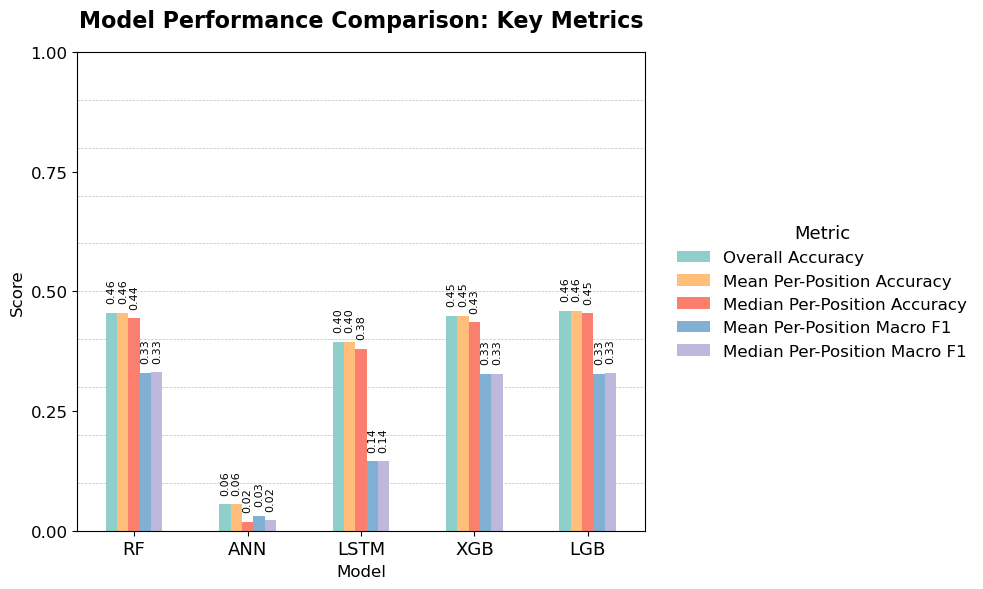

In [12]:
# Pastel color palette for metrics
metric_colors = [
    '#8ECFC9',   # Overall Accuracy (minty teal)
    '#FFBE7A',   # Mean Per-Position Accuracy (pastel orange)
    '#FA7F6F',   # Median Per-Position Accuracy (coral)
    '#82B0D2',   # Mean Per-Position Macro F1 (blue)
    '#BEB8DC'    # Median Per-Position Macro F1 (lavender)
]

metrics_to_plot = [
    'Overall Accuracy',
    'Mean Per-Position Accuracy',
    'Median Per-Position Accuracy',
    'Mean Per-Position Macro F1',
    'Median Per-Position Macro F1'
]

plot_df = metrics_summary[metrics_summary['Metric'].isin(metrics_to_plot)].set_index('Metric')
plot_df = plot_df[['RF', 'ANN', 'LSTM', 'XGB', 'LGB']]

fig, ax = plt.subplots(figsize=(10, 6))

# Transpose for group-by-model bars
plot_df.T.plot(kind='bar', ax=ax, color=metric_colors, zorder=2)

# Add horizontal guidelines
for y in np.arange(0, 1.1, 0.1):
    ax.axhline(y, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)

plt.title('Model Performance Comparison: Key Metrics', fontsize=16, fontweight='bold', pad=18)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 1)
plt.yticks([0, 0.25, 0.5, 0.75, 1.0], fontsize=12)
plt.xticks(rotation=0, fontsize=13)
plt.legend(
    title='Metric', bbox_to_anchor=(1.03, 0.5), loc='center left', fontsize=12, title_fontsize=13, frameon=False
)

# Add value labels above bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(
            f'{height:.2f}',
            (p.get_x() + p.get_width() / 2., height + 0.02),
            ha='center',
            va='bottom',
            fontsize=8,
            color='black',
            rotation=90
        )

plt.tight_layout()
plt.show()

### Analysis of Model Performance Comparison: Key Metrics

The above grouped bar chart compares five models (Random Forest, ANN, LSTM, XGBoost, LightGBM) across several core performance metrics:

- **Overall Accuracy**
- **Mean Per-Position Accuracy**
- **Median Per-Position Accuracy**
- **Mean Per-Position Macro F1**
- **Median Per-Position Macro F1**

#### **Key Observations:**

- **Tree-Based Models Lead Performance:**  
  Random Forest, XGBoost, and LightGBM achieve the highest scores for all accuracy-based metrics (overall, mean, and median per-position accuracy), closely followed by one another. Their macro F1 scores also substantially outperform the neural network models.

- **ANN Significantly Underperforms:**  
  The ANN model scores near zero for all metrics, indicating an inability to learn meaningful predictive relationships from the environmental data for this task.

- **LSTM Performs Moderately:**  
  LSTM achieves better scores than ANN, especially in accuracy metrics, but remains well below the ensemble tree-based models and does not challenge their dominance in F1 or accuracy.

- **Consistency Across Metrics:**  
  There is strong consistency between overall accuracy and per-position accuracy (mean and median), reflecting stable model behavior. Similarly, mean and median macro F1 scores track closely, indicating that the majority of nucleotide positions are predicted with similar (not just extreme) performance.

- **No Single Dominant Model:**  
  Among tree-based models, LightGBM edges slightly ahead in overall and mean accuracy, but all three ensemble models are highly competitive, suggesting robustness of tree ensembles for this application.

### Radar (spider) plot for accuracy and macro F1 distribution

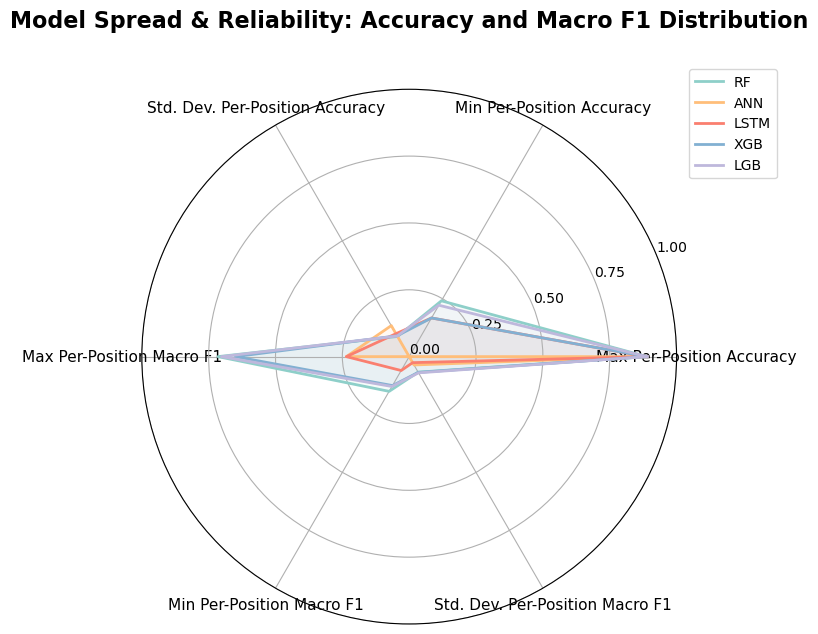

In [13]:
radar_metrics = [
    'Max Per-Position Accuracy',
    'Min Per-Position Accuracy',
    'Std. Dev. Per-Position Accuracy',
    'Max Per-Position Macro F1',
    'Min Per-Position Macro F1',
    'Std. Dev. Per-Position Macro F1'
]

# Subset and transpose
radar_df = metrics_summary[metrics_summary['Metric'].isin(radar_metrics)].set_index('Metric')
radar_df = radar_df[['RF', 'ANN', 'LSTM', 'XGB', 'LGB']].T

labels = radar_df.columns.tolist()
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Color palette for each model
colors = ['#8ECFC9', '#FFBE7A', '#FA7F6F', '#82B0D2', '#BEB8DC']

for i, model in enumerate(radar_df.index):
    values = radar_df.loc[model].tolist()
    values += values[:1]  # loop back to the start
    ax.plot(angles, values, label=model, linewidth=2, color=colors[i])
    ax.fill(angles, values, alpha=0.08, color=colors[i])

ax.set_title('Model Spread & Reliability: Accuracy and Macro F1 Distribution', y=1.10, fontsize=16, fontweight='bold')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_ylim(0, 1)

# Rotate y-labels for clarity
ax.yaxis.set_tick_params(labelsize=10)

ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05))
plt.tight_layout()
plt.show()

### Analysis of Model Spread & Reliability: Accuracy and Macro F1 Distribution

The radar plot above summarizes the distribution characteristics of both per-position accuracy and macro F1 scores for each model, focusing on spread (min, max, standard deviation) and reliability:

#### **Key Insights:**

- **Maximal Performance:**  
  All models achieve identical maximum per-position accuracy (0.889) and similar maximum macro F1 (highest for RF and LGB), indicating some genomic positions are easy for all models.

- **Minimum Performance:**  
  The minimum per-position accuracy and macro F1 are much lower for ANN and LSTM, with ANN dropping to zero, showing a much greater risk of total failure at certain positions. In contrast, RF, XGB, and LGB maintain higher minimums, reflecting more reliable baseline performance.

- **Model Stability (Standard Deviation):**  
  The standard deviation bars reveal that RF, XGB, and LGB exhibit the lowest spread in both accuracy and macro F1, confirming consistent and dependable performance across the entire genome. LSTM and especially ANN display higher variability, indicating instability and unreliability.

- **Comparative Model Reliability:**  
  LightGBM and Random Forest show the best combination of high minimum accuracy/F1 and low standard deviation, making them the most robust and stable choices for nucleotide-level prediction using environmental data.

### Heatmap for all metrics

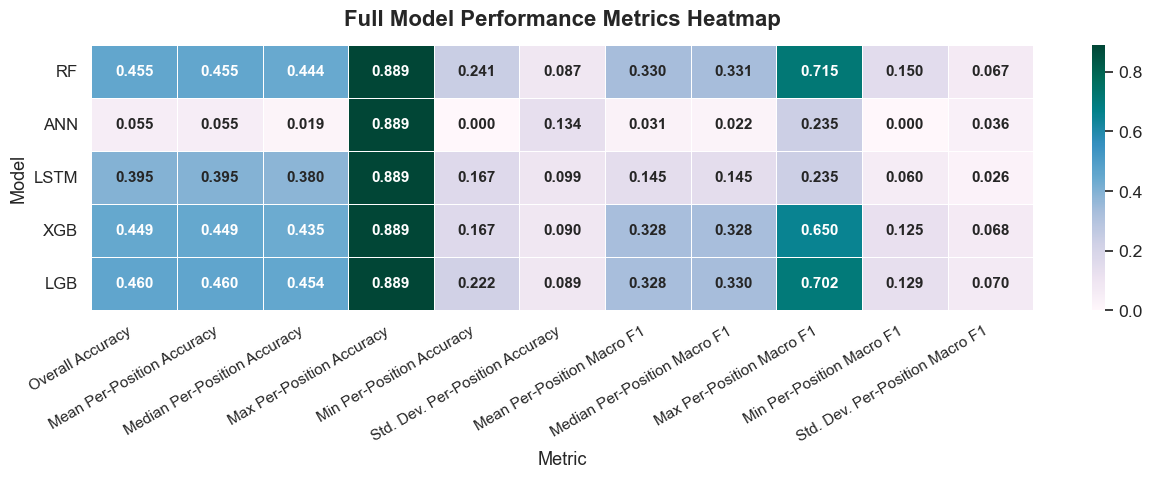

In [14]:
# Set 'Metric' as index for plotting (transpose for Model on y-axis, Metric on x-axis)
heatmap_df = metrics_summary.set_index('Metric').T

plt.figure(figsize=(13, 5))
sns.set(font_scale=1.15)

# Use a pastel theme color palette
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="PuBuGn",          
    linewidths=0.6,
    cbar=True,
    annot_kws={"size": 11, "weight": "bold"},
    linecolor='white',
    square=False
)

plt.title('Full Model Performance Metrics Heatmap', fontsize=16, fontweight='bold', pad=14)
plt.ylabel('Model', fontsize=13)
plt.xlabel('Metric', fontsize=13)
plt.yticks(fontsize=12, rotation=0)
plt.xticks(fontsize=11, rotation=30, ha='right')
plt.tight_layout()
plt.show() 

### Analysis of Full Model Performance Metrics Heatmap

The heatmap above provides a comprehensive comparison of all five models across a suite of summary metrics for per-position accuracy and macro F1-score.

#### **Key Observations:**

- **Overall Performance:**
  - **LightGBM (LGB)** achieves the highest overall accuracy (0.460), closely followed by **Random Forest (RF)** (0.455) and **XGBoost (XGB)** (0.449).
  - **ANN** significantly underperforms all other models across all metrics, with both overall accuracy and mean per-position macro F1 below 0.06.

- **Accuracy Distribution:**
  - All models achieve the same maximum per-position accuracy (0.889), indicating some genomic positions are universally predictable.
  - **LGB** and **RF** have higher minimum per-position accuracy (0.222 and 0.241, respectively), while **ANN** and **LSTM** drop as low as 0.0 and 0.167, revealing instability.
  - **RF** has the lowest standard deviation in accuracy (0.087), indicating more consistent predictions across all positions.

- **Macro F1 Distribution:**
  - **RF** has the highest mean and median per-position macro F1 (0.330 and 0.331), slightly above **LGB** (0.328/0.330) and **XGB** (0.328).
  - Maximum macro F1 is again highest for **RF** (0.715), but **LGB** is close (0.702).
  - **ANN** exhibits the lowest minimum macro F1 (0.000) and a low standard deviation, but this reflects consistently poor performance rather than stability.

- **Reliability:**
  - **Tree-based ensemble models** (RF, LGB, XGB) are the most robust, combining high accuracy, high macro F1, and low variability.
  - **LSTM** performs moderately, but falls short of tree models in both accuracy and F1, though it is superior to ANN.

#### **Conclusion:**
- **LightGBM** and **Random Forest** emerge as the strongest, most reliable models for this nucleotide prediction task, balancing both accuracy and class-wise F1-score.
- **XGBoost** also performs strongly and nearly matches the leaders in most metrics.
- **ANN** is clearly unsuited for this task or data, and **LSTM** only offers partial improvement.

### Winner plot (best-performer for each metric)

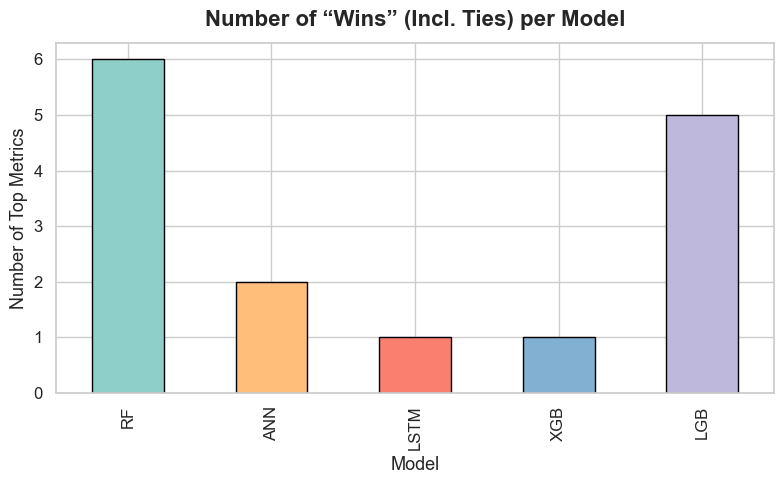

In [15]:
plot_df = metrics_summary.set_index('Metric')[['RF', 'ANN', 'LSTM', 'XGB', 'LGB']]

# Count wins including ties
wins_tied = pd.DataFrame((plot_df == plot_df.max(axis=1, skipna=True).values[:, None]).astype(int), columns=plot_df.columns)

# Sum wins for each model
winner_counts_tied = wins_tied.sum(axis=0)

# Plot
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
ax = winner_counts_tied.plot(
    kind='bar',
    color=['#8ECFC9', '#FFBE7A', '#FA7F6F', '#82B0D2', '#BEB8DC'],
    edgecolor='black'
)
plt.title('Number of “Wins” (Incl. Ties) per Model', fontsize=16, fontweight='bold', pad=12)
plt.ylabel('Number of Top Metrics', fontsize=13)
plt.xlabel('Model', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### Analysis of Number of "Wins" (Incl. Ties) per Model

The bar chart above visualizes how many times each model achieved the top score across the full set of performance metrics, counting tied values as wins for all tying models.

#### **Key Observations:**

- **Random Forest (RF)** and **LightGBM (LGB)** dominate, with RF leading at 6 wins and LGB close behind at 5, confirming their overall superior performance across diverse metrics.
- **Artificial Neural Network (ANN)**, despite weak overall performance, secures 2 wins due to ties—typically in metrics such as maximum values where all models reach the same best score.
- **LSTM** and **XGBoost (XGB)** each achieve only 1 win, reflecting their relatively weaker and less consistent performance compared to RF and LGB.
- The inclusion of ties shows that ANN, LSTM, and XGB can occasionally match the top models on specific metrics, but their overall dominance is lacking.

#### **Conclusion:**
- The tally of wins reaffirms that **RF** and **LGB** are the most competitive and reliable models for the nucleotide prediction task.
- **ANN**'s wins are due to ties, not overall strength, while **LSTM** and **XGB** trail further behind.
- This win-count perspective complements the previous metric-by-metric analyses, highlighting which models repeatedly stand out across a suite of evaluation criteria.

# Conclusion

This project systematically evaluated five machine learning models—Random Forest, ANN, LSTM, XGBoost, and LightGBM—for forecasting nucleotide-level genomic evolution in Dengue virus using environmental variables such as temperature and atmospheric CO₂. Comprehensive analysis of accuracy and macro F1 metrics revealed that tree-based models, particularly Random Forest and LightGBM, consistently outperformed neural architectures in this climate-aware mutation prediction task. These results demonstrate that environmental data can provide predictive power for genomic forecasting, and highlight the importance of model selection when tackling complex bioinformatics challenges. The comparative study not only identifies top-performing algorithms but also establishes a robust methodological framework for future viral evolution modeling.